# Praktikum Pertemuan 5: Forecasting

Notebook ini mengikuti Modul Pertemuan 5 (Forecasting). Model memprediksi nilai periode berikutnya
dari data historis memakai MLP, KNN, Decision Tree, SVR, dan Random Forest, lalu dievaluasi dengan
RMSE dan Pearson Correlation Coefficient.

**Dataset percobaan:** Bike Sharing (`bikesharing_day.csv`)

**Dataset tugas:** Tesla Stock Data 2010-2020 (`TSLA.CSV`)


## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
from math import sqrt
import matplotlib.pyplot as plt
import seaborn as sns

from numpy import array
from scipy.stats import pearsonr, kurtosis, skew
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

print('Library siap dipakai.')


Library siap dipakai.


## 2. Fungsi Sliding Window

`split_sequences` mengubah deret waktu menjadi pasangan input-output. Input berisi `n_steps_in`
nilai sebelumnya, output berisi nilai pada `n_steps_out` langkah berikutnya.


In [2]:
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        if out_end_ix > len(sequences):
            break
        seq_x, seq_y = sequences[i:end_ix, :-1], sequences[out_end_ix - 1, -1]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)


## 3. Fungsi Fitur Statistik

`stats_features` menambahkan delapan fitur statistik (min, max, max-min, std, mean, median,
kurtosis, skewness) pada tiap jendela, sehingga model punya gambaran distribusi data dalam window.


In [3]:
def stats_features(input_data):
    inp = list()
    for i in range(len(input_data)):
        inp2 = input_data[i]
        min_val = float(np.min(inp2))
        max_val = float(np.max(inp2))
        diff = max_val - min_val
        std_val = float(np.std(inp2))
        mean_val = float(np.mean(inp2))
        median_val = float(np.median(inp2))
        kurt = float(kurtosis(inp2))
        sk = float(skew(inp2))
        for v in (min_val, max_val, diff, std_val, mean_val, median_val, kurt, sk):
            inp2 = np.append(inp2, v)
        inp = np.append(inp, inp2)
    return inp.reshape(len(input_data), -1)


## 4. Fungsi Model Machine Learning

Lima fungsi model, masing-masing melatih model, memprediksi data uji, lalu mengembalikan
RMSE, Pearson correlation, dan hasil prediksi.


In [4]:
def mlp(X_train, X_test, y_train, y_test):
    model = MLPRegressor(random_state=42)
    model.fit(X_train, y_train)
    y_pred = np.round(model.predict(X_test), 0)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    corr, _ = pearsonr(y_test, y_pred)
    return rmse, corr, y_pred

def knn(X_train, X_test, y_train, y_test):
    model = KNeighborsRegressor()
    model.fit(X_train, y_train)
    y_pred = np.round(model.predict(X_test), 0)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    corr, _ = pearsonr(y_test, y_pred)
    return rmse, corr, y_pred

def dt(X_train, X_test, y_train, y_test):
    model = DecisionTreeRegressor(random_state=42)
    model.fit(X_train, y_train)
    y_pred = np.round(model.predict(X_test), 0)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    corr, _ = pearsonr(y_test, y_pred)
    return rmse, corr, y_pred

def svm(X_train, X_test, y_train, y_test):
    model = SVR()
    model.fit(X_train, y_train)
    y_pred = np.round(model.predict(X_test), 0)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    corr, _ = pearsonr(y_test, y_pred)
    return rmse, corr, y_pred

def rf(X_train, X_test, y_train, y_test):
    model = RandomForestRegressor(random_state=42)
    model.fit(X_train, y_train)
    y_pred = np.round(model.predict(X_test), 0)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    corr, _ = pearsonr(y_test, y_pred)
    return rmse, corr, y_pred


## 5. Baca Dataset Bike Sharing

In [5]:
df = pd.read_csv('https://raw.githubusercontent.com/ganjar87/data_science_practice/main/bikesharing_day.csv')
print('shape:', df.shape)
df.head()


shape: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [6]:
df_ori = df.copy()
df_ori['date'] = pd.to_datetime(df_ori['dteday'])
df_ori['cnt'].iloc[:10]


0     985
1     801
2    1349
3    1562
4    1600
5    1606
6    1510
7     959
8     822
9    1321
Name: cnt, dtype: int64

## 6. Preprocessing: Sliding Window, Split, Fitur Statistik

Input memakai nilai `cnt` 7 hari sebelumnya untuk memprediksi hari ke-8. Data dibagi 80:20
dengan `shuffle=False` agar urutan waktu terjaga.


In [7]:
df_X = df_ori[['cnt', 'cnt']]
in_seq = df_X.astype(float).values

n_steps_in, n_steps_out = 7, 1
X, y = split_sequences(in_seq, n_steps_in, n_steps_out)
print('X mentah:', X.shape)
print('X[0]:', X[0].ravel())
print('y[0]:', y[0])

n_input = X.shape[1] * X.shape[2]
X = X.reshape((X.shape[0], n_input))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False)

X_train = stats_features(X_train)
X_test = stats_features(X_test)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)


X mentah: (724, 7, 1)
X[0]: [ 985.  801. 1349. 1562. 1600. 1606. 1510.]
y[0]: 959.0


X_train: (579, 15) | X_test: (145, 15)


### Visualisasi Deret Waktu `cnt`

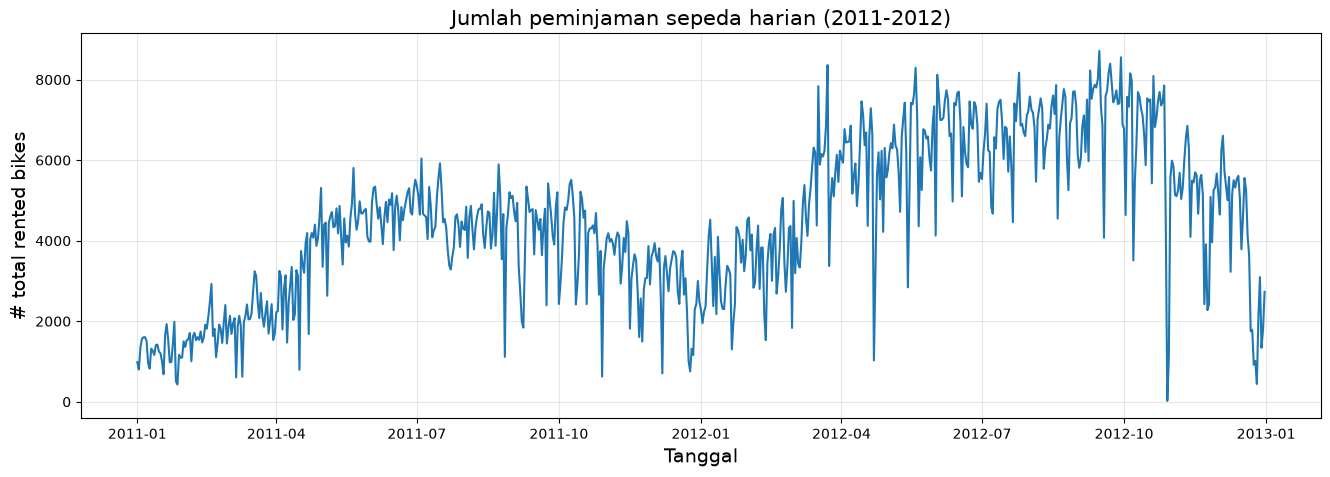

In [8]:
fig = plt.figure(figsize=(16, 5))
plt.plot(df_ori['date'], df_ori['cnt'])
plt.ylabel('# total rented bikes', fontsize=14)
plt.xlabel('Tanggal', fontsize=14)
plt.title('Jumlah peminjaman sepeda harian (2011-2012)', fontsize=15)
plt.grid(alpha=0.3)
plt.show()


## 7. Pelatihan dan Prediksi Model

In [9]:
rmse_mlp, corr_mlp, y_pred_mlp = mlp(X_train, X_test, y_train, y_test)
rmse_knn, corr_knn, y_pred_knn = knn(X_train, X_test, y_train, y_test)
rmse_dt, corr_dt, y_pred_dt = dt(X_train, X_test, y_train, y_test)
rmse_svm, corr_svm, y_pred_svm = svm(X_train, X_test, y_train, y_test)
rmse_rf, corr_rf, y_pred_rf = rf(X_train, X_test, y_train, y_test)
print('Semua model selesai dilatih.')


Semua model selesai dilatih.


## 8. Visualisasi Hasil Prediksi

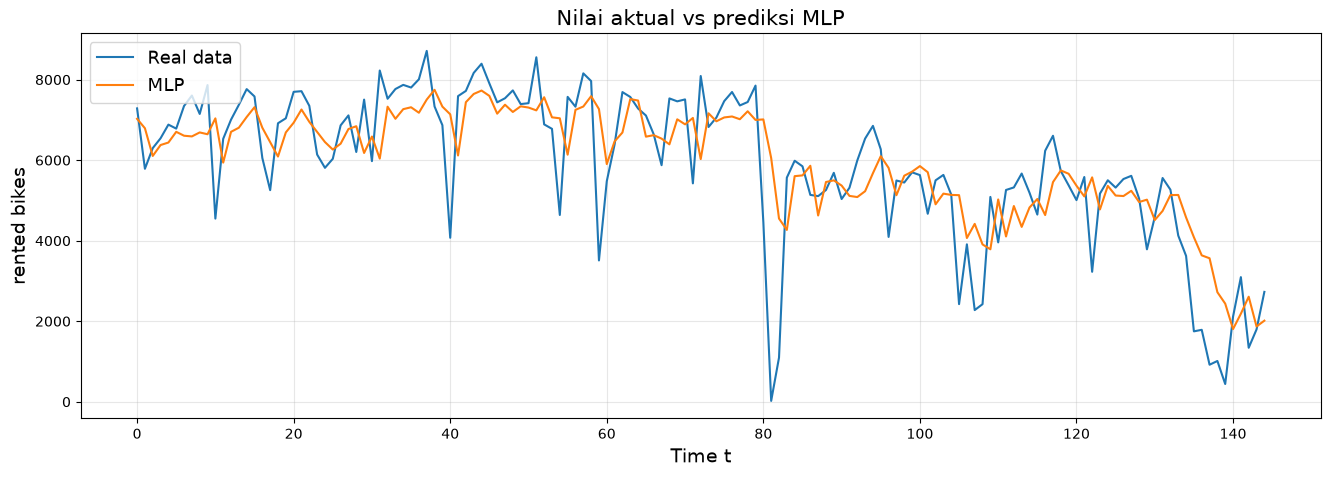

In [10]:
fig = plt.figure(figsize=(16, 5))
plt.plot(y_test, label='Real data')
plt.plot(y_pred_mlp, label='MLP')
plt.xlabel('Time t', fontsize=14)
plt.ylabel('rented bikes', fontsize=14)
plt.title('Nilai aktual vs prediksi MLP', fontsize=15)
plt.legend(loc='upper left', fontsize=13)
plt.grid(alpha=0.3)
plt.show()


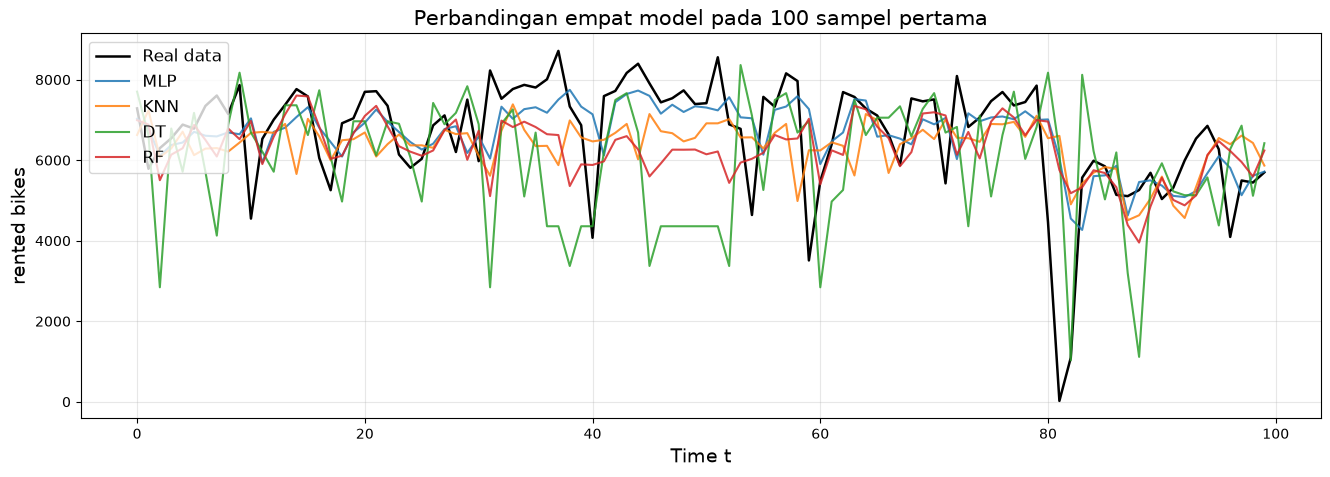

In [11]:
fig = plt.figure(figsize=(16, 5))
plt.plot(y_test[:100], label='Real data', color='black', linewidth=1.8)
plt.plot(y_pred_mlp[:100], label='MLP', alpha=0.85)
plt.plot(y_pred_knn[:100], label='KNN', alpha=0.85)
plt.plot(y_pred_dt[:100], label='DT', alpha=0.85)
plt.plot(y_pred_rf[:100], label='RF', alpha=0.85)
plt.xlabel('Time t', fontsize=14)
plt.ylabel('rented bikes', fontsize=14)
plt.title('Perbandingan empat model pada 100 sampel pertama', fontsize=15)
plt.legend(loc='upper left', fontsize=12)
plt.grid(alpha=0.3)
plt.show()


## 9. Evaluasi Model

In [12]:
for name, rmse, corr in [
    ('MLP', rmse_mlp, corr_mlp),
    ('KNN', rmse_knn, corr_knn),
    ('DT', rmse_dt, corr_dt),
    ('SVR', rmse_svm, corr_svm),
    ('RF', rmse_rf, corr_rf),
]:
    print('________________________')
    print(name)
    print('RMSE: %.3f' % rmse)
    print('Pearson correlation coefficient: %.3f' % corr)


________________________
MLP
RMSE: 1190.549
Pearson correlation coefficient: 0.778
________________________
KNN
RMSE: 1357.710
Pearson correlation coefficient: 0.696
________________________
DT
RMSE: 1854.465
Pearson correlation coefficient: 0.484
________________________
SVR
RMSE: 2404.928
Pearson correlation coefficient: 0.644
________________________
RF
RMSE: 1324.452
Pearson correlation coefficient: 0.716


### Perbandingan dengan Baseline Naif

Model dibandingkan dengan baseline sederhana yang memprediksi nilai besok sama dengan nilai
hari terakhir pada jendela, untuk melihat apakah model benar-benar belajar pola.


In [13]:
last_value = X[:, -1]
rmse_naive = sqrt(mean_squared_error(y_test, last_value[-len(y_test):]))
corr_naive, _ = pearsonr(y_test, last_value[-len(y_test):])
print('naive RMSE: %.3f | Pearson: %.3f' % (rmse_naive, corr_naive))


naive RMSE: 1290.766 | Pearson: 0.763


## 10. Tugas: Forecasting Harga Saham Tesla

Dataset: Tesla Stock Data 2010-2020 (mirror GitHub). Dua skenario dikerjakan:

- **Skenario A:** prediksi `Close` 2 hari ke depan dari `Close` 7 hari sebelumnya.
- **Skenario B:** prediksi `Close` 2 hari ke depan dari `Close` dan `Open` 7 hari sebelumnya.


In [14]:
ts = pd.read_csv('https://raw.githubusercontent.com/0xpranjal/Stock-Prediction-using-different-models/main/TSLA.CSV')
print('shape:', ts.shape)
print('rentang:', ts['Date'].iloc[0], '->', ts['Date'].iloc[-1])
ts.head()


shape: (2657, 8)
rentang: 2010-06-29 -> 2021-01-15


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29,3.80,5.00,3.51,4.78,93831500,0,0.0
1,2010-06-30,5.16,6.08,4.66,4.77,85935500,0,0.0
2,2010-07-01,5.00,5.18,4.05,4.39,41094000,0,0.0
3,2010-07-02,4.60,4.62,3.74,3.84,25699000,0,0.0
4,2010-07-06,4.00,4.00,3.17,3.22,34334500,0,0.0


### Skenario A: fitur `Close` saja

In [15]:
df_A = ts[['Close', 'Close']]
seq_A = df_A.astype(float).values
XA, yA = split_sequences(seq_A, 7, 2)
XA = XA.reshape((XA.shape[0], XA.shape[1] * XA.shape[2]))
XA_tr, XA_te, yA_tr, yA_te = train_test_split(XA, yA, test_size=0.2, random_state=42, shuffle=False)
XA_tr = stats_features(XA_tr)
XA_te = stats_features(XA_te)
print('XA_train:', XA_tr.shape, '| XA_test:', XA_te.shape)

resA = {}
resA['MLP'] = mlp(XA_tr, XA_te, yA_tr, yA_te)
resA['KNN'] = knn(XA_tr, XA_te, yA_tr, yA_te)
resA['DT']  = dt(XA_tr, XA_te, yA_tr, yA_te)
resA['SVR'] = svm(XA_tr, XA_te, yA_tr, yA_te)
resA['RF']  = rf(XA_tr, XA_te, yA_tr, yA_te)

for name, (rmse, corr, _) in resA.items():
    print('%-4s RMSE: %.3f | Pearson: %.3f' % (name, rmse, corr))


XA_train: (2119, 15) | XA_test: (530, 15)


/home/hafidzprasetya/Kuliah/PPD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP  RMSE: 18.766 | Pearson: 0.995
KNN  RMSE: 215.366 | Pearson: 0.564
DT   RMSE: 215.814 | Pearson: 0.554
SVR  RMSE: 235.231 | Pearson: -0.568
RF   RMSE: 216.154 | Pearson: 0.541


### Skenario B: fitur `Close` dan `Open`

In [16]:
df_B = ts[['Close', 'Open', 'Close']]
seq_B = df_B.astype(float).values
XB, yB = split_sequences(seq_B, 7, 2)
XB = XB.reshape((XB.shape[0], XB.shape[1] * XB.shape[2]))
XB_tr, XB_te, yB_tr, yB_te = train_test_split(XB, yB, test_size=0.2, random_state=42, shuffle=False)
XB_tr = stats_features(XB_tr)
XB_te = stats_features(XB_te)
print('XB_train:', XB_tr.shape, '| XB_test:', XB_te.shape)

resB = {}
resB['MLP'] = mlp(XB_tr, XB_te, yB_tr, yB_te)
resB['KNN'] = knn(XB_tr, XB_te, yB_tr, yB_te)
resB['DT']  = dt(XB_tr, XB_te, yB_tr, yB_te)
resB['SVR'] = svm(XB_tr, XB_te, yB_tr, yB_te)
resB['RF']  = rf(XB_tr, XB_te, yB_tr, yB_te)

for name, (rmse, corr, _) in resB.items():
    print('%-4s RMSE: %.3f | Pearson: %.3f' % (name, rmse, corr))


XB_train: (2119, 22) | XB_test: (530, 22)


MLP  RMSE: 18.010 | Pearson: 0.996
KNN  RMSE: 215.342 | Pearson: 0.565
DT   RMSE: 215.883 | Pearson: 0.543
SVR  RMSE: 235.261 | Pearson: -0.566
RF   RMSE: 215.876 | Pearson: 0.548


### Perbandingan Skenario A vs B

In [17]:
rows = []
for name in ['MLP', 'KNN', 'DT', 'SVR', 'RF']:
    rows.append({
        'Model': name,
        'RMSE_A': round(resA[name][0], 3), 'Pearson_A': round(resA[name][1], 3),
        'RMSE_B': round(resB[name][0], 3), 'Pearson_B': round(resB[name][1], 3),
    })
comp = pd.DataFrame(rows)
comp


,Model,RMSE_A,Pearson_A,RMSE_B,Pearson_B
0,MLP,18.766,0.995,18.010,0.996
1,KNN,215.366,0.564,215.342,0.565
2,DT,215.814,0.554,215.883,0.543
3,SVR,235.231,-0.568,235.261,-0.566
4,RF,216.154,0.541,215.876,0.548


### Visualisasi Prediksi Tesla (Skenario B, model terbaik)

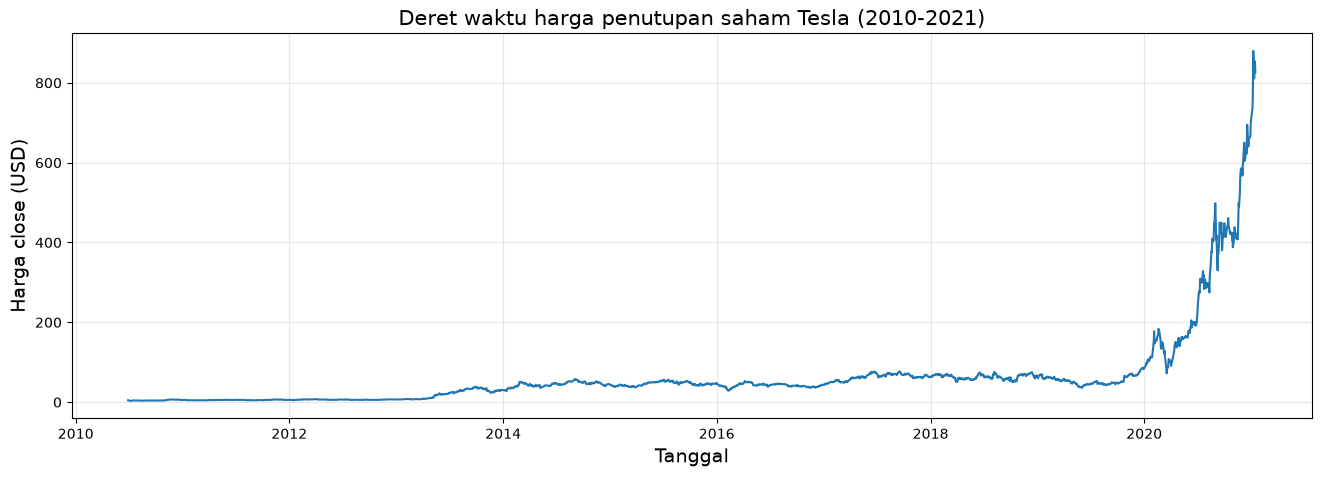

In [18]:
ts2 = ts.copy()
ts2['Date'] = pd.to_datetime(ts2['Date'])
fig = plt.figure(figsize=(16, 5))
plt.plot(ts2['Date'], ts2['Close'])
plt.ylabel('Harga close (USD)', fontsize=14)
plt.xlabel('Tanggal', fontsize=14)
plt.title('Deret waktu harga penutupan saham Tesla (2010-2021)', fontsize=15)
plt.grid(alpha=0.3)
plt.show()


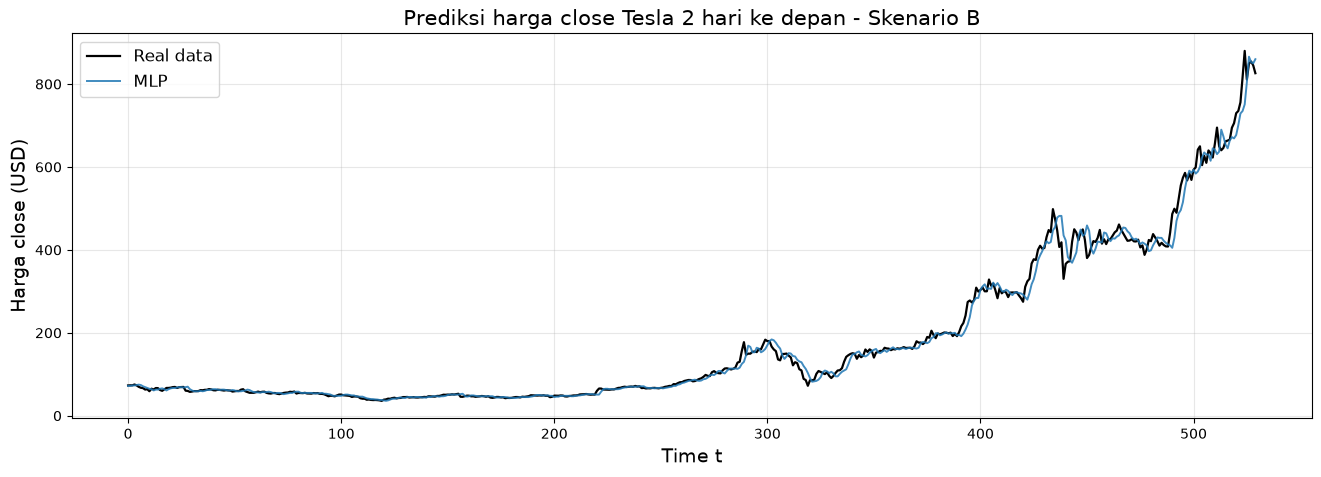

In [19]:
_, _, yB_pred = resB['MLP']
fig = plt.figure(figsize=(16, 5))
plt.plot(yB_te, label='Real data', color='black', linewidth=1.6)
plt.plot(yB_pred, label='MLP', linewidth=1.4, alpha=0.85)
plt.xlabel('Time t', fontsize=14)
plt.ylabel('Harga close (USD)', fontsize=14)
plt.title('Prediksi harga close Tesla 2 hari ke depan - Skenario B', fontsize=15)
plt.legend(loc='upper left', fontsize=12)
plt.grid(alpha=0.3)
plt.show()
